# Stop-Loss Benchmark and Bear Recovery Simulation

This notebook focuses on two questions:

1. If I set a stop loss today, how much recovery from that stop price is needed to match selling today after tax?
2. If a bear drawdown happens, is holding and hoping for recovery better than selling today after tax under my recovery assumptions?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:,.2f}".format

## Inputs

Update these values with your real position data and your candidate stop-loss levels.

In [2]:
# Position inputs.
shares = 35
current_price = 350.0
cost_basis_per_share = 124.0
capital_gains_tax_rate = 0.26

# Candidate stop losses, expressed as drops from today's price.
stop_loss_drops = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50])

# Used only to choose a highlighted benchmark stop.
# Example: 0.30 means you are willing to require at most a 30% rebound from the stop price.
benchmark_recovery_tolerance = 0.30

# Re-entry assumptions for the stop-and-reenter strategy.
# 0.00 means perfect re-entry at the bear low.
# 0.05 means re-entry happens 5% above the bear low.
# This models missed timing, slippage, spreads, and execution drag.
reentry_slippage_from_bear_low = 0.05

# Optional extra transaction cost as a fraction of trade value.
# Example: 0.005 means 0.5% cost on sale and re-entry.
transaction_cost_rate = 0.00

# Re-entry buys whole shares only. Leftover cash remains uninvested.
allow_fractional_reentry_shares = False

# Bear-market recovery assumptions.
# This generates bear drawdowns every 1%, from -5% to -60%.
# Adjust the start/end values if you want a narrower or wider bear-market range.
bear_drawdown_start = -0.05
bear_drawdown_end = -0.60
bear_drawdown_step = -0.01

bear_drawdowns = np.round(
    np.arange(bear_drawdown_start, bear_drawdown_end + bear_drawdown_step, bear_drawdown_step),
    4,
)

# Recovery assumptions are generated as formulas so the 1% grid stays easy to edit.
# recovery_return_from_low is the assumed rebound from each drawdown low if recovery happens.
# recovery_probability declines as the drawdown gets deeper.
bear_recovery_cases = pd.DataFrame({
    "drawdown": bear_drawdowns,
})
bear_recovery_cases["case"] = bear_recovery_cases["drawdown"].apply(lambda x: f"Bear {x:.0%}")
bear_recovery_cases["recovery_return_from_low"] = np.maximum(
    0.10,
    np.minimum(1.50, bear_recovery_cases["drawdown"].abs() * 1.50),
)
bear_recovery_cases["recovery_probability"] = np.maximum(
    0.10,
    0.70 - bear_recovery_cases["drawdown"].abs(),
)
bear_recovery_cases = bear_recovery_cases[[
    "case",
    "drawdown",
    "recovery_return_from_low",
    "recovery_probability",
]]

bear_recovery_cases

,case,drawdown,recovery_return_from_low,recovery_probability
0,Bear -5%,-0.05,0.10,0.65
1,Bear -6%,-0.06,0.10,0.64
2,Bear -7%,-0.07,0.11,0.63
3,Bear -8%,-0.08,0.12,0.62
4,Bear -9%,-0.09,0.14,0.61
5,Bear -10%,-0.10,0.15,0.60
6,Bear -11%,-0.11,0.17,0.59
7,Bear -12%,-0.12,0.18,0.58
8,Bear -13%,-0.13,0.20,0.57
9,Bear -14%,-0.14,0.21,0.56


## Core Tax Functions

In [3]:
def taxable_gain_at_sale(price, shares, basis_per_share):
    return max((price - basis_per_share) * shares, 0)


def tax_due_at_sale(price, shares, basis_per_share, tax_rate):
    return taxable_gain_at_sale(price, shares, basis_per_share) * tax_rate


def after_tax_liquidation_value(price, shares, basis_per_share, tax_rate):
    gross_value = price * shares
    tax_due = tax_due_at_sale(price, shares, basis_per_share, tax_rate)
    return gross_value - tax_due


def required_price_for_after_tax_value(target_after_tax_value):
    low = 0.0
    high = max(current_price * 10, cost_basis_per_share * 10, 1.0)

    while after_tax_liquidation_value(high, shares, cost_basis_per_share, capital_gains_tax_rate) < target_after_tax_value:
        high *= 2

    for _ in range(100):
        mid = (low + high) / 2
        value = after_tax_liquidation_value(mid, shares, cost_basis_per_share, capital_gains_tax_rate)
        if value < target_after_tax_value:
            low = mid
        else:
            high = mid

    return high

## Sell Today Baseline

This is the benchmark both questions compare against: sell today, pay capital gains tax, and keep the after-tax cash.

In [4]:
current_gross_value = current_price * shares
current_unrealized_gain = taxable_gain_at_sale(current_price, shares, cost_basis_per_share)
tax_if_sold_today = current_unrealized_gain * capital_gains_tax_rate
sell_today_after_tax_value = current_gross_value - tax_if_sold_today
required_recovery_price = required_price_for_after_tax_value(sell_today_after_tax_value)

baseline = pd.Series({
    "shares": shares,
    "current_price": current_price,
    "cost_basis_per_share": cost_basis_per_share,
    "current_gross_value": current_gross_value,
    "current_unrealized_gain": current_unrealized_gain,
    "tax_if_sold_today": tax_if_sold_today,
    "sell_today_after_tax_value": sell_today_after_tax_value,
    "required_recovery_price_to_match_selling_today": required_recovery_price,
})

baseline

shares                                               35.00
current_price                                       350.00
cost_basis_per_share                                124.00
current_gross_value                              12,250.00
current_unrealized_gain                           7,910.00
tax_if_sold_today                                 2,056.60
sell_today_after_tax_value                       10,193.40
required_recovery_price_to_match_selling_today      350.00
dtype: float64

## Question 1: Stop-Loss Benchmark

This table answers: if I let the position fall to each stop price, how much must it rebound from there to match selling today after tax?

`required_recovery_from_stop_to_match_selling_today` is the key column.

In [5]:
benchmark_rows = []

for drop in stop_loss_drops:
    stop_price = current_price * (1 - drop)
    after_tax_at_stop = after_tax_liquidation_value(
        stop_price, shares, cost_basis_per_share, capital_gains_tax_rate
    )
    required_recovery_from_stop = (required_recovery_price / stop_price) - 1

    benchmark_rows.append({
        "stop_loss_drop": drop,
        "stop_price": stop_price,
        "after_tax_value_if_stopped": after_tax_at_stop,
        "after_tax_loss_vs_selling_today": after_tax_at_stop - sell_today_after_tax_value,
        "after_tax_loss_vs_selling_today_pct": (after_tax_at_stop / sell_today_after_tax_value) - 1,
        "required_recovery_price_to_match_selling_today": required_recovery_price,
        "required_recovery_from_stop_to_match_selling_today": required_recovery_from_stop,
    })

stop_benchmark_df = pd.DataFrame(benchmark_rows)
stop_benchmark_df

,stop_loss_drop,stop_price,after_tax_value_if_stopped,after_tax_loss_vs_selling_today,after_tax_loss_vs_selling_today_pct,required_recovery_price_to_match_selling_today,required_recovery_from_stop_to_match_selling_today
0,0.05,332.50,"9,740.15",-453.25,-0.04,350.00,0.05
1,0.10,315.00,"9,286.90",-906.50,-0.09,350.00,0.11
2,0.15,297.50,"8,833.65","-1,359.75",-0.13,350.00,0.18
3,0.20,280.00,"8,380.40","-1,813.00",-0.18,350.00,0.25
4,0.25,262.50,"7,927.15","-2,266.25",-0.22,350.00,0.33
5,0.30,245.00,"7,473.90","-2,719.50",-0.27,350.00,0.43
6,0.40,210.00,"6,567.40","-3,626.00",-0.36,350.00,0.67
7,0.50,175.00,"5,660.90","-4,532.50",-0.44,350.00,1.00


## Best Benchmark Stop

This highlights the deepest tested stop where the required rebound from the stop price is no more than `benchmark_recovery_tolerance`.

In [6]:
eligible_stops = stop_benchmark_df[
    stop_benchmark_df["required_recovery_from_stop_to_match_selling_today"] <= benchmark_recovery_tolerance
]

if eligible_stops.empty:
    best_benchmark_stop = stop_benchmark_df.head(1).iloc[0]
    benchmark_note = (
        f"No tested stop has required recovery at or below {benchmark_recovery_tolerance:.0%}. "
        "Showing the tightest tested stop instead."
    )
else:
    best_benchmark_stop = eligible_stops.tail(1).iloc[0]
    benchmark_note = (
        f"Deepest tested stop where required recovery is at or below {benchmark_recovery_tolerance:.0%}."
    )

pd.Series({
    "benchmark_rule": benchmark_note,
    "best_benchmark_stop_loss_drop": best_benchmark_stop["stop_loss_drop"],
    "best_benchmark_stop_price": best_benchmark_stop["stop_price"],
    "after_tax_value_if_stopped": best_benchmark_stop["after_tax_value_if_stopped"],
    "after_tax_loss_vs_selling_today": best_benchmark_stop["after_tax_loss_vs_selling_today"],
    "required_recovery_price_to_match_selling_today": best_benchmark_stop["required_recovery_price_to_match_selling_today"],
    "required_recovery_from_stop_to_match_selling_today": best_benchmark_stop["required_recovery_from_stop_to_match_selling_today"],
})

benchmark_rule                                        Deepest tested stop where required recovery is...
best_benchmark_stop_loss_drop                                                                      0.20
best_benchmark_stop_price                                                                        280.00
after_tax_value_if_stopped                                                                     8,380.40
after_tax_loss_vs_selling_today                                                               -1,813.00
required_recovery_price_to_match_selling_today                                                   350.00
required_recovery_from_stop_to_match_selling_today                                                 0.25
dtype: object

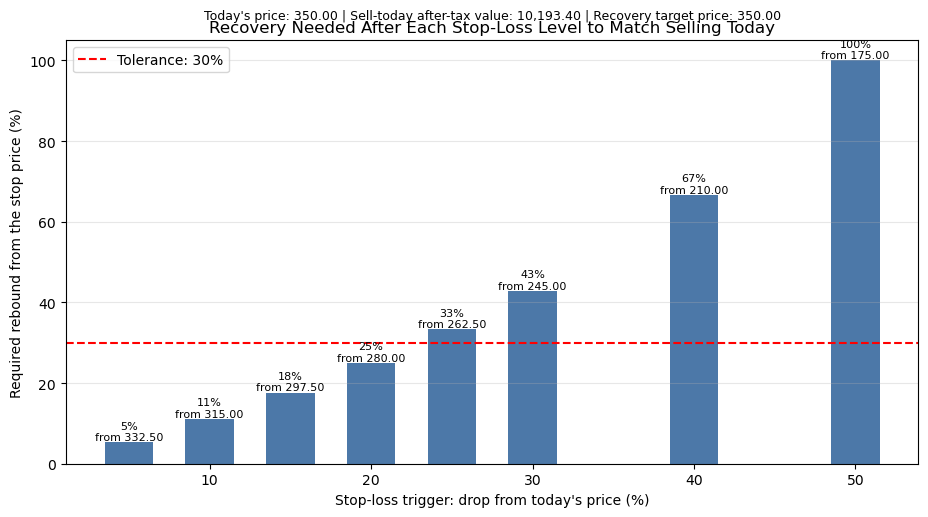

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5))

x = stop_benchmark_df["stop_loss_drop"] * 100
y = stop_benchmark_df["required_recovery_from_stop_to_match_selling_today"] * 100

ax.bar(x, y, width=3, color="#4C78A8")
ax.axhline(benchmark_recovery_tolerance * 100, color="red", linestyle="--", label=f"Tolerance: {benchmark_recovery_tolerance:.0%}")
ax.set_title("Recovery Needed After Each Stop-Loss Level to Match Selling Today")
ax.set_xlabel("Stop-loss trigger: drop from today's price (%)")
ax.set_ylabel("Required rebound from the stop price (%)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

subtitle = (
    f"Today's price: {current_price:,.2f} | "
    f"Sell-today after-tax value: {sell_today_after_tax_value:,.2f} | "
    f"Recovery target price: {required_recovery_price:,.2f}"
)
ax.text(0.5, 1.05, subtitle, transform=ax.transAxes, ha="center", fontsize=9)

for _, row in stop_benchmark_df.iterrows():
    ax.text(
        row["stop_loss_drop"] * 100,
        row["required_recovery_from_stop_to_match_selling_today"] * 100,
        f"{row['required_recovery_from_stop_to_match_selling_today']:.0%}\nfrom {row['stop_price']:,.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.show()

## Question 2: Bear Recovery Analysis

This table answers: if a bear drawdown happens, is holding and hoping for recovery better than selling today after tax under the recovery assumptions?

`expected_after_tax_value_if_hold_for_recovery` uses each row's `recovery_probability`. It is recovery value times recovery probability, plus drawdown value times the probability recovery does not happen.

If `expected_difference_vs_selling_today` is positive, holding through that bear drawdown is better than selling today under that row's assumptions.

In [8]:
recovery_rows = []

for _, case in bear_recovery_cases.iterrows():
    drawdown_price = current_price * (1 + case["drawdown"])
    recovery_price = drawdown_price * (1 + case["recovery_return_from_low"])

    after_tax_at_drawdown = after_tax_liquidation_value(
        drawdown_price, shares, cost_basis_per_share, capital_gains_tax_rate
    )
    after_tax_after_recovery = after_tax_liquidation_value(
        recovery_price, shares, cost_basis_per_share, capital_gains_tax_rate
    )

    expected_hold_for_recovery = (
        case["recovery_probability"] * after_tax_after_recovery
        + (1 - case["recovery_probability"]) * after_tax_at_drawdown
    )

    recovery_rows.append({
        "case": case["case"],
        "drawdown": case["drawdown"],
        "drawdown_price": drawdown_price,
        "after_tax_value_if_sold_at_drawdown": after_tax_at_drawdown,
        "recovery_return_from_low": case["recovery_return_from_low"],
        "recovery_price": recovery_price,
        "recovery_probability": case["recovery_probability"],
        "after_tax_value_if_recovery_happens": after_tax_after_recovery,
        "expected_after_tax_value_if_hold_for_recovery": expected_hold_for_recovery,
        "expected_difference_vs_selling_today": expected_hold_for_recovery - sell_today_after_tax_value,
        "required_recovery_price_to_match_selling_today": required_recovery_price,
        "required_recovery_return_from_low_to_match_selling_today": (required_recovery_price / drawdown_price) - 1,
    })

bear_recovery_df = pd.DataFrame(recovery_rows)
bear_case_order = bear_recovery_df.sort_values("drawdown", ascending=False)["case"].tolist()
bear_recovery_df

,case,drawdown,drawdown_price,after_tax_value_if_sold_at_drawdown,recovery_return_from_low,recovery_price,recovery_probability,after_tax_value_if_recovery_happens,expected_after_tax_value_if_hold_for_recovery,expected_difference_vs_selling_today,required_recovery_price_to_match_selling_today,required_recovery_return_from_low_to_match_selling_today
0,Bear -5%,-0.05,332.50,"9,740.15",0.10,365.75,0.65,"10,601.33","10,299.91",106.51,350.00,0.05
1,Bear -6%,-0.06,329.00,"9,649.50",0.10,361.90,0.64,"10,501.61","10,194.85",1.45,350.00,0.06
2,Bear -7%,-0.07,325.50,"9,558.85",0.11,359.68,0.63,"10,444.05","10,116.52",-76.88,350.00,0.08
3,Bear -8%,-0.08,322.00,"9,468.20",0.12,360.64,0.62,"10,468.98","10,088.68",-104.72,350.00,0.09
4,Bear -9%,-0.09,318.50,"9,377.55",0.14,361.50,0.61,"10,491.19","10,056.87",-136.53,350.00,0.10
5,Bear -10%,-0.10,315.00,"9,286.90",0.15,362.25,0.60,"10,510.67","10,021.17",-172.23,350.00,0.11
6,Bear -11%,-0.11,311.50,"9,196.25",0.17,362.90,0.59,"10,527.45","9,981.66",-211.74,350.00,0.12
7,Bear -12%,-0.12,308.00,"9,105.60",0.18,363.44,0.58,"10,541.50","9,938.42",-254.98,350.00,0.14
8,Bear -13%,-0.13,304.50,"9,014.95",0.20,363.88,0.57,"10,552.83","9,891.54",-301.86,350.00,0.15
9,Bear -14%,-0.14,301.00,"8,924.30",0.21,364.21,0.56,"10,561.44","9,841.10",-352.30,350.00,0.16


## Combined Benchmark: Stop Losses vs Bear Scenarios

This combines Question 1 and Question 2.

For each candidate stop loss and each bear scenario, the table asks:

- Would this stop trigger before or at the bear drawdown?
- If the stop triggers, what rebound from the stop price is required to match selling today?
- Is the bear scenario's assumed recovery enough to clear that required rebound?

`covered_by_stop` means the bear drawdown is at least as deep as the stop loss, so the stop would trigger before or at that drawdown.

`assumed_recovery_clears_required_recovery` compares the scenario's assumed recovery from the drawdown low with the recovery required from the stop price. This is an approximation because the assumed recovery starts from the bear low, while the stop benchmark starts from the stop price.

`expected_difference_vs_selling_today_if_hold_for_recovery` comes from the bear scenario itself. It shows whether holding through that bear scenario has positive expected value versus selling today.

In [9]:
combined_rows = []

for _, stop in stop_benchmark_df.iterrows():
    for _, scenario in bear_recovery_df.iterrows():
        covered_by_stop = abs(scenario["drawdown"]) >= stop["stop_loss_drop"]
        assumed_recovery_clears_required = (
            scenario["recovery_return_from_low"]
            >= stop["required_recovery_from_stop_to_match_selling_today"]
        )

        combined_rows.append({
            "stop_loss_drop": stop["stop_loss_drop"],
            "stop_price": stop["stop_price"],
            "bear_case": scenario["case"],
            "bear_drawdown": scenario["drawdown"],
            "covered_by_stop": covered_by_stop,
            "required_recovery_from_stop_to_match_selling_today": stop["required_recovery_from_stop_to_match_selling_today"],
            "assumed_recovery_from_bear_low": scenario["recovery_return_from_low"],
            "assumed_recovery_clears_required_recovery": assumed_recovery_clears_required,
            "recovery_probability": scenario["recovery_probability"],
            "expected_difference_vs_selling_today_if_hold_for_recovery": scenario["expected_difference_vs_selling_today"],
        })

stop_vs_bear_df = pd.DataFrame(combined_rows)
stop_vs_bear_df

,stop_loss_drop,stop_price,bear_case,bear_drawdown,covered_by_stop,required_recovery_from_stop_to_match_selling_today,assumed_recovery_from_bear_low,assumed_recovery_clears_required_recovery,recovery_probability,expected_difference_vs_selling_today_if_hold_for_recovery
0,0.05,332.50,Bear -5%,-0.05,True,0.05,0.10,True,0.65,106.51
1,0.05,332.50,Bear -6%,-0.06,True,0.05,0.10,True,0.64,1.45
2,0.05,332.50,Bear -7%,-0.07,True,0.05,0.11,True,0.63,-76.88
3,0.05,332.50,Bear -8%,-0.08,True,0.05,0.12,True,0.62,-104.72
4,0.05,332.50,Bear -9%,-0.09,True,0.05,0.14,True,0.61,-136.53
...,...,...,...,...,...,...,...,...,...,...
443,0.50,175.00,Bear -56%,-0.56,True,1.00,0.84,False,0.14,"-4,607.34"
444,0.50,175.00,Bear -57%,-0.57,True,1.00,0.85,False,0.13,"-4,733.79"
445,0.50,175.00,Bear -58%,-0.58,True,1.00,0.87,False,0.12,"-4,860.22"
446,0.50,175.00,Bear -59%,-0.59,True,1.00,0.89,False,0.11,"-4,986.53"


In [10]:
stop_vs_bear_matrix = stop_vs_bear_df.pivot_table(
    index=["stop_loss_drop", "stop_price", "required_recovery_from_stop_to_match_selling_today"],
    columns="bear_case",
    values="assumed_recovery_clears_required_recovery",
    aggfunc="first",
)
stop_vs_bear_matrix = stop_vs_bear_matrix.reindex(columns=bear_case_order)

stop_vs_bear_matrix

,,bear_case,Bear -5%,Bear -6%,Bear -7%,Bear -8%,Bear -9%,Bear -10%,Bear -11%,Bear -12%,Bear -13%,Bear -14%,...,Bear -51%,Bear -52%,Bear -53%,Bear -54%,Bear -55%,Bear -56%,Bear -57%,Bear -58%,Bear -59%,Bear -60%
stop_loss_drop,stop_price,required_recovery_from_stop_to_match_selling_today,,,,,,,,,,,,,,,,,,,,,
0.05,332.50,0.05,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
0.10,315.00,0.11,False,False,False,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
0.15,297.50,0.18,False,False,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
0.20,280.00,0.25,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
0.25,262.50,0.33,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
0.30,245.00,0.43,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
0.40,210.00,0.67,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
0.50,175.00,1.00,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


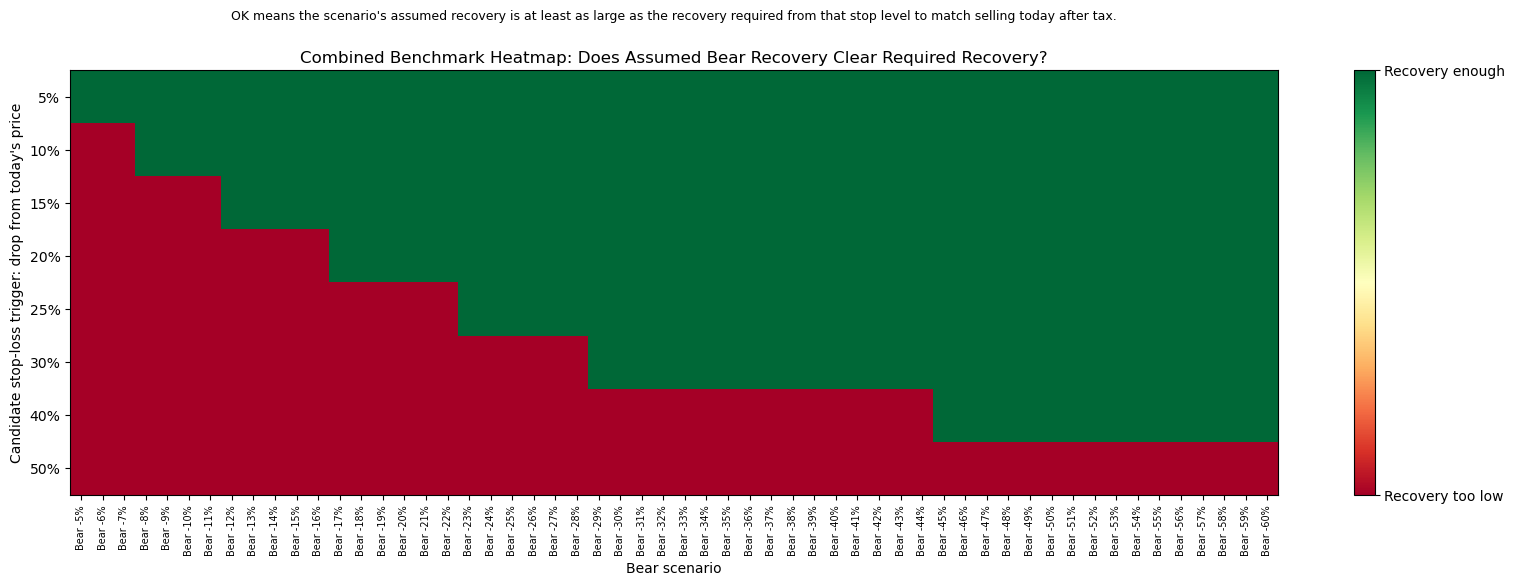

In [11]:
heatmap_df = stop_vs_bear_df.pivot_table(
    index="stop_loss_drop",
    columns="bear_case",
    values="assumed_recovery_clears_required_recovery",
    aggfunc="first",
).reindex(columns=bear_case_order).astype(int)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(heatmap_df.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

ax.set_title("Combined Benchmark Heatmap: Does Assumed Bear Recovery Clear Required Recovery?")
ax.set_xlabel("Bear scenario")
ax.set_ylabel("Candidate stop-loss trigger: drop from today's price")

ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=90, ha="center", fontsize=7)
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels([f"{x:.0%}" for x in heatmap_df.index])

cbar = fig.colorbar(im, ax=ax, ticks=[0, 1])
cbar.ax.set_yticklabels(["Recovery too low", "Recovery enough"])

subtitle = (
    "OK means the scenario's assumed recovery is at least as large as "
    "the recovery required from that stop level to match selling today after tax."
)
ax.text(0.5, 1.12, subtitle, transform=ax.transAxes, ha="center", fontsize=9)

plt.tight_layout()
plt.show()

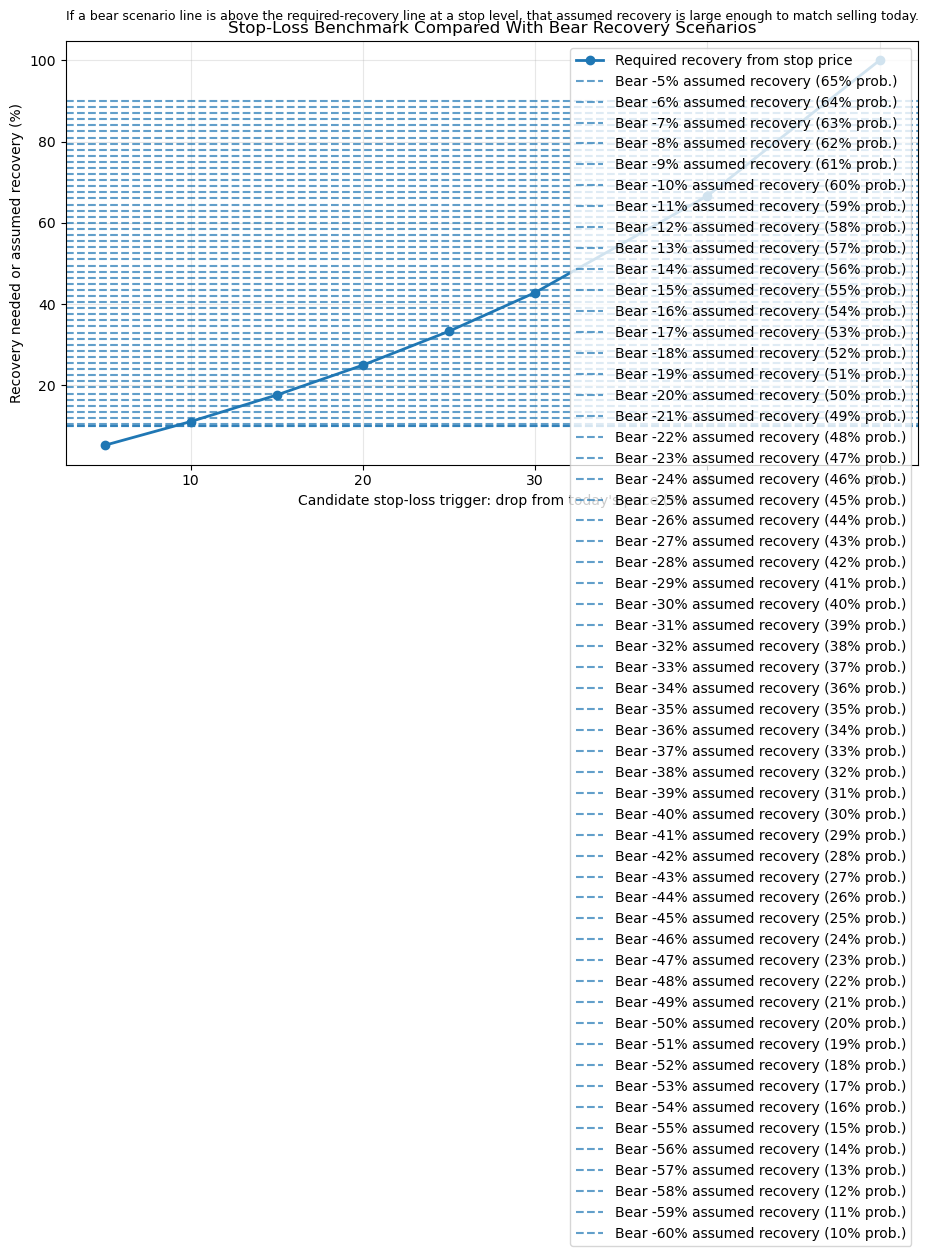

In [12]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(
    stop_benchmark_df["stop_loss_drop"] * 100,
    stop_benchmark_df["required_recovery_from_stop_to_match_selling_today"] * 100,
    marker="o",
    linewidth=2,
    label="Required recovery from stop price",
)

for _, scenario in bear_recovery_df.iterrows():
    ax.axhline(
        scenario["recovery_return_from_low"] * 100,
        linestyle="--",
        alpha=0.7,
        label=f"{scenario['case']} assumed recovery ({scenario['recovery_probability']:.0%} prob.)",
    )

ax.set_title("Stop-Loss Benchmark Compared With Bear Recovery Scenarios")
ax.set_xlabel("Candidate stop-loss trigger: drop from today's price (%)")
ax.set_ylabel("Recovery needed or assumed recovery (%)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

subtitle = (
    "If a bear scenario line is above the required-recovery line at a stop level, "
    "that assumed recovery is large enough to match selling today."
)
ax.text(0.5, 1.05, subtitle, transform=ax.transAxes, ha="center", fontsize=9)

plt.show()

## Strategy Test: Stop + Re-entry vs Hold

This section directly tests the question: if a bear scenario happens, is it better to trigger a stop loss, pay 26% tax, re-enter lower, and ride the recovery, or simply hold through the drawdown?

The re-entry price is configurable:

`reentry_slippage_from_bear_low = 0.00` means perfect re-entry at the bear low.

`reentry_slippage_from_bear_low = 0.05` means re-entry happens 5% above the bear low.

`transaction_cost_rate` can model execution costs on the stop sale and the re-entry purchase.

`allow_fractional_reentry_shares = False` means re-entry buys only whole shares and leaves unused cash uninvested.

`stop_reentry_advantage_vs_hold_after_recovery` is the key column. Positive means the stop + re-entry strategy beats simply holding through that bear scenario and recovery. Negative means holding was better.

In [13]:
strategy_rows = []

for _, stop in stop_benchmark_df.iterrows():
    for _, scenario in bear_recovery_df.iterrows():
        stop_triggers = abs(scenario["drawdown"]) >= stop["stop_loss_drop"]
        bear_low_price = scenario["drawdown_price"]
        recovery_price = scenario["recovery_price"]
        reentry_price = bear_low_price * (1 + reentry_slippage_from_bear_low)

        hold_after_recovery_after_tax = after_tax_liquidation_value(
            recovery_price, shares, cost_basis_per_share, capital_gains_tax_rate
        )

        if stop_triggers:
            stop_sale_cash_after_tax = stop["after_tax_value_if_stopped"]
            stop_sale_cash_after_tax *= (1 - transaction_cost_rate)

            reentry_cash_after_cost = stop_sale_cash_after_tax * (1 - transaction_cost_rate)
            raw_reentry_shares = reentry_cash_after_cost / reentry_price

            if allow_fractional_reentry_shares:
                reentry_shares = raw_reentry_shares
            else:
                reentry_shares = np.floor(raw_reentry_shares)

            leftover_cash_after_reentry = reentry_cash_after_cost - (reentry_shares * reentry_price)
            stop_reentry_gross_recovery_value = (reentry_shares * recovery_price) + leftover_cash_after_reentry
            stop_reentry_after_tax_value = stop_reentry_gross_recovery_value
            stop_reentry_note = "Stop triggered; re-entered"
        else:
            raw_reentry_shares = shares
            reentry_shares = shares
            leftover_cash_after_reentry = 0.0
            stop_reentry_after_tax_value = hold_after_recovery_after_tax
            stop_reentry_note = "Stop not triggered; same as hold"

        advantage = stop_reentry_after_tax_value - hold_after_recovery_after_tax

        strategy_rows.append({
            "stop_loss_drop": stop["stop_loss_drop"],
            "stop_price": stop["stop_price"],
            "bear_case": scenario["case"],
            "bear_drawdown": scenario["drawdown"],
            "stop_triggers": stop_triggers,
            "bear_low_price": bear_low_price,
            "reentry_price": reentry_price,
            "reentry_slippage_from_bear_low": reentry_slippage_from_bear_low,
            "raw_reentry_shares_before_rounding": raw_reentry_shares,
            "reentry_shares_after_tax_and_costs": reentry_shares,
            "leftover_cash_after_reentry": leftover_cash_after_reentry,
            "recovery_price": recovery_price,
            "hold_after_recovery_after_tax": hold_after_recovery_after_tax,
            "stop_reentry_after_recovery_value": stop_reentry_after_tax_value,
            "stop_reentry_advantage_vs_hold_after_recovery": advantage,
            "stop_reentry_advantage_vs_hold_after_recovery_pct": (stop_reentry_after_tax_value / hold_after_recovery_after_tax) - 1,
            "note": stop_reentry_note,
        })

stop_reentry_vs_hold_df = pd.DataFrame(strategy_rows)
stop_reentry_vs_hold_df

,stop_loss_drop,stop_price,bear_case,bear_drawdown,stop_triggers,bear_low_price,reentry_price,reentry_slippage_from_bear_low,raw_reentry_shares_before_rounding,reentry_shares_after_tax_and_costs,leftover_cash_after_reentry,recovery_price,hold_after_recovery_after_tax,stop_reentry_after_recovery_value,stop_reentry_advantage_vs_hold_after_recovery,stop_reentry_advantage_vs_hold_after_recovery_pct,note
0,0.05,332.50,Bear -5%,-0.05,True,332.50,349.12,0.05,27.90,27.00,313.77,365.75,"10,601.33","10,189.03",-412.30,-0.04,Stop triggered; re-entered
1,0.05,332.50,Bear -6%,-0.06,True,329.00,345.45,0.05,28.20,28.00,67.55,361.90,"10,501.61","10,200.75",-300.86,-0.03,Stop triggered; re-entered
2,0.05,332.50,Bear -7%,-0.07,True,325.50,341.78,0.05,28.50,28.00,170.45,359.68,"10,444.05","10,241.42",-202.63,-0.02,Stop triggered; re-entered
3,0.05,332.50,Bear -8%,-0.08,True,322.00,338.10,0.05,28.81,28.00,273.35,360.64,"10,468.98","10,371.27",-97.71,-0.01,Stop triggered; re-entered
4,0.05,332.50,Bear -9%,-0.09,True,318.50,334.43,0.05,29.13,29.00,41.82,361.50,"10,491.19","10,525.25",34.07,0.00,Stop triggered; re-entered
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,0.50,175.00,Bear -56%,-0.56,True,154.00,161.70,0.05,35.01,35.00,1.40,283.36,"8,467.42","9,919.00","1,451.58",0.17,Stop triggered; re-entered
444,0.50,175.00,Bear -57%,-0.57,True,150.50,158.03,0.05,35.82,35.00,130.02,279.18,"8,359.10","9,901.24","1,542.14",0.18,Stop triggered; re-entered
445,0.50,175.00,Bear -58%,-0.58,True,147.00,154.35,0.05,36.68,36.00,104.30,274.89,"8,248.05","10,000.34","1,752.29",0.21,Stop triggered; re-entered
446,0.50,175.00,Bear -59%,-0.59,True,143.50,150.68,0.05,37.57,37.00,85.92,270.50,"8,134.29","10,094.33","1,960.05",0.24,Stop triggered; re-entered


In [14]:
stop_reentry_summary = stop_reentry_vs_hold_df[stop_reentry_vs_hold_df["stop_triggers"]].copy()

best_stop_reentry_by_case = (
    stop_reentry_summary
    .sort_values("stop_reentry_advantage_vs_hold_after_recovery", ascending=False)
    .groupby("bear_case", as_index=False)
    .first()
    [[
        "bear_case",
        "bear_drawdown",
        "stop_loss_drop",
        "stop_price",
        "reentry_price",
        "recovery_price",
        "raw_reentry_shares_before_rounding",
        "reentry_shares_after_tax_and_costs",
        "leftover_cash_after_reentry",
        "hold_after_recovery_after_tax",
        "stop_reentry_after_recovery_value",
        "stop_reentry_advantage_vs_hold_after_recovery",
        "stop_reentry_advantage_vs_hold_after_recovery_pct",
    ]]
)

best_stop_reentry_by_case

,bear_case,bear_drawdown,stop_loss_drop,stop_price,reentry_price,recovery_price,raw_reentry_shares_before_rounding,reentry_shares_after_tax_and_costs,leftover_cash_after_reentry,hold_after_recovery_after_tax,stop_reentry_after_recovery_value,stop_reentry_advantage_vs_hold_after_recovery,stop_reentry_advantage_vs_hold_after_recovery_pct
0,Bear -10%,-0.10,0.05,332.50,330.75,362.25,29.45,29.00,148.40,"10,510.67","10,653.65",142.98,0.01
1,Bear -11%,-0.11,0.05,332.50,327.07,362.90,29.78,29.00,254.98,"10,527.45","10,779.00",251.56,0.02
2,Bear -12%,-0.12,0.05,332.50,323.40,363.44,30.12,30.00,38.15,"10,541.50","10,941.35",399.85,0.04
3,Bear -13%,-0.13,0.05,332.50,319.73,363.88,30.46,30.00,148.40,"10,552.83","11,064.73",511.90,0.05
4,Bear -14%,-0.14,0.05,332.50,316.05,364.21,30.82,30.00,258.65,"10,561.44","11,184.95",623.51,0.06
5,Bear -15%,-0.15,0.05,332.50,312.38,364.44,31.18,31.00,56.52,"10,567.33","11,354.09",786.76,0.07
6,Bear -16%,-0.16,0.05,332.50,308.70,364.56,31.55,31.00,170.45,"10,570.50","11,471.81",901.31,0.09
7,Bear -17%,-0.17,0.05,332.50,305.03,364.58,31.93,31.00,284.37,"10,570.96","11,586.28","1,015.32",0.10
8,Bear -18%,-0.18,0.05,332.50,301.35,364.49,32.32,32.00,96.95,"10,568.69","11,760.63","1,191.94",0.11
9,Bear -19%,-0.19,0.05,332.50,297.68,364.30,32.72,32.00,214.55,"10,563.71","11,872.07","1,308.36",0.12


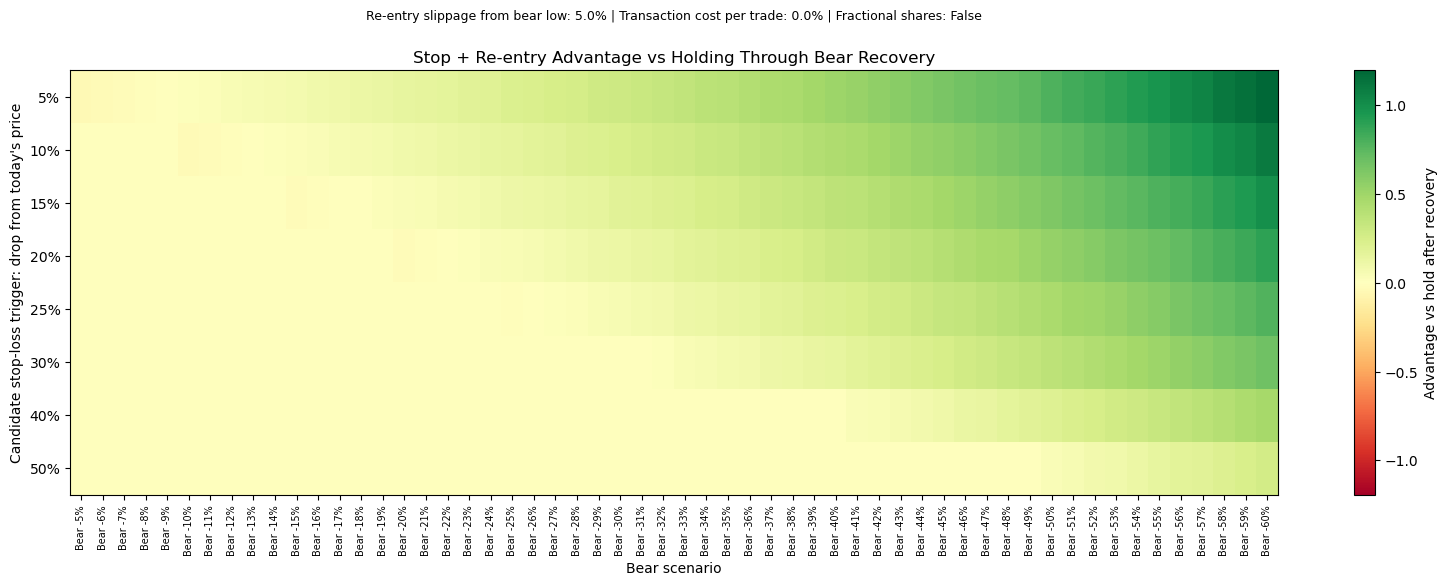

In [15]:
strategy_heatmap_df = stop_reentry_vs_hold_df.pivot_table(
    index="stop_loss_drop",
    columns="bear_case",
    values="stop_reentry_advantage_vs_hold_after_recovery_pct",
    aggfunc="first",
)
strategy_heatmap_df = strategy_heatmap_df.reindex(columns=bear_case_order)

fig, ax = plt.subplots(figsize=(16, 6))
max_abs = np.nanmax(np.abs(strategy_heatmap_df.values))
max_abs = max(max_abs, 0.01)
im = ax.imshow(strategy_heatmap_df.values, cmap="RdYlGn", vmin=-max_abs, vmax=max_abs, aspect="auto")

ax.set_title("Stop + Re-entry Advantage vs Holding Through Bear Recovery")
ax.set_xlabel("Bear scenario")
ax.set_ylabel("Candidate stop-loss trigger: drop from today's price")
ax.set_xticks(np.arange(len(strategy_heatmap_df.columns)))
ax.set_xticklabels(strategy_heatmap_df.columns, rotation=90, ha="center", fontsize=7)
ax.set_yticks(np.arange(len(strategy_heatmap_df.index)))
ax.set_yticklabels([f"{x:.0%}" for x in strategy_heatmap_df.index])

cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Advantage vs hold after recovery")

subtitle = (
    f"Re-entry slippage from bear low: {reentry_slippage_from_bear_low:.1%} | "
    f"Transaction cost per trade: {transaction_cost_rate:.1%} | "
    f"Fractional shares: {allow_fractional_reentry_shares}"
)
ax.text(0.5, 1.12, subtitle, transform=ax.transAxes, ha="center", fontsize=9)

plt.tight_layout()
plt.show()

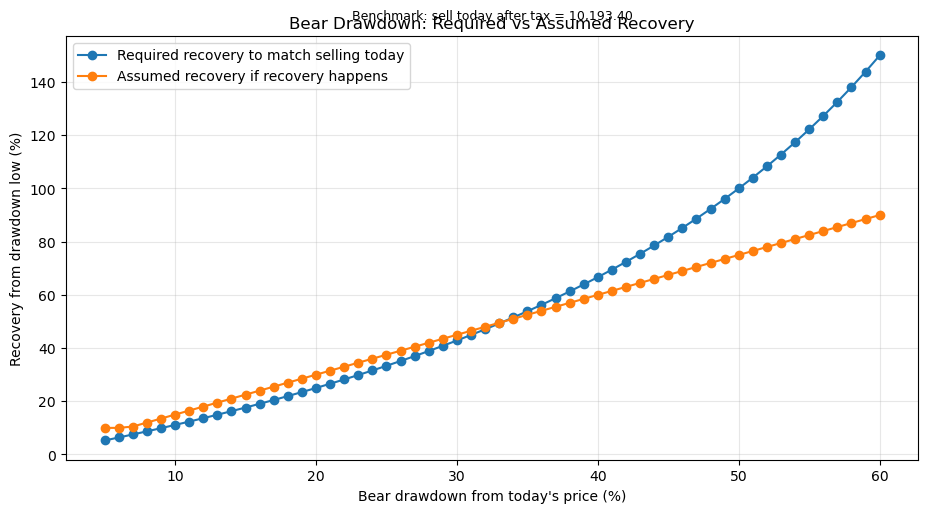

In [16]:
fig, ax = plt.subplots(figsize=(11, 5.5))

x = bear_recovery_df["drawdown"].abs() * 100
required = bear_recovery_df["required_recovery_return_from_low_to_match_selling_today"] * 100
assumed = bear_recovery_df["recovery_return_from_low"] * 100

ax.plot(x, required, marker="o", label="Required recovery to match selling today")
ax.plot(x, assumed, marker="o", label="Assumed recovery if recovery happens")
ax.set_title("Bear Drawdown: Required vs Assumed Recovery")
ax.set_xlabel("Bear drawdown from today's price (%)")
ax.set_ylabel("Recovery from drawdown low (%)")
ax.grid(True, alpha=0.3)
ax.legend()

subtitle = f"Benchmark: sell today after tax = {sell_today_after_tax_value:,.2f}"
ax.text(0.5, 1.04, subtitle, transform=ax.transAxes, ha="center", fontsize=9)

plt.show()